In [1]:
import warnings
from json import dumps
from pickle import Pickler
from shutil import rmtree
from pathlib import Path
from typing import Literal
from gzip import open as gz_open
from joblib import Parallel, delayed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, minmax_scale
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer
from sklearn.metrics import average_precision_score
from sklearn.model_selection import GridSearchCV
from statsmodels.stats.outliers_influence import variance_inflation_factor


RANDOM_STATE = 12345
VIF_THRESHOLD = 6.0

# Dados

In [2]:
def prepare_experiment(
    which: Literal["full", "iot", "control", "infra"],
    target: Literal["binary", "grouped", "all"],
    overwrite: bool = False,
):
    experiment = {}
    dataset_path = Path("../datasense/dataset/")
    for split in ["train", "test"]:
        split_data = dataset_path / f"datasense_{which}_{split}_1sec.parquet"
        split_data = pd.read_parquet(split_data)
        if target == "binary":
            y_split = split_data["label1"]
        elif target == "grouped":
            y_split = split_data["label2"]
        else:
            y_split = split_data["label4"]
        experiment[split] = (split_data, y_split)
    experiment["classes"] = sorted(experiment["train"][1].unique())
    log1p_transformer = FunctionTransformer(np.log1p, feature_names_out="one-to-one")
    number_selector = make_column_selector(dtype_include="number")
    bool_selector = make_column_selector(dtype_include="bool")
    if which == "full":
        experiment["normalizer"] = make_column_transformer(
            (make_pipeline(log1p_transformer, MinMaxScaler()), number_selector),
            (OneHotEncoder(sparse_output=False), ["device_type"]),
            ("passthrough", bool_selector),
            verbose_feature_names_out=False,
        )
    else:
        experiment["normalizer"] = make_column_transformer(
            (make_pipeline(log1p_transformer, MinMaxScaler()), number_selector),
            ("passthrough", bool_selector),
            verbose_feature_names_out=False,
        )
    results_dir = Path("results")
    results_dir /= f"logistic_regression_{which}_{target}"
    if results_dir.is_dir():
        if overwrite:
            rmtree(results_dir, ignore_errors=True)
        else:
            raise RuntimeError("Experiment already executed and overwrite set to False")
    results_dir.mkdir(exist_ok=True, parents=True)
    cache_dir = results_dir / ".cache"
    cache_dir.mkdir()
    experiment["results_dir"] = results_dir
    experiment["cache_dir"] = str(cache_dir)
    return experiment

In [3]:
experiment = prepare_experiment(which="full", target="all", overwrite=True)

X_train, y_train = experiment["train"]
class_names = experiment["classes"]
num_classes = len(class_names)
X_test, y_test = experiment["test"]
results_dir = experiment["results_dir"]
cache_dir = experiment["cache_dir"]

# Colinear features removal

In [4]:
def _vif(data, i):
    with warnings.catch_warnings():
        warnings.simplefilter(action="ignore", category=RuntimeWarning)
        return variance_inflation_factor(data, i)


def get_vif_features_out(
    data: np.ndarray,
    feature_names: list[str],
    vif_threshold: float = 5.0,
    num_samples: int = 30000,
) -> pd.Series:
    feature_names = list(feature_names)
    rng = np.random.default_rng(seed=RANDOM_STATE)
    sample_idxs = rng.choice(data.shape[0], size=num_samples)
    data_sample = np.ones((num_samples, data.shape[1] + 1), dtype=float)
    data_sample[:, :-1] = data[sample_idxs]
    to_remove = {"index": [], "data": []}
    while True:
        vifs = np.array(
            Parallel(n_jobs=6)(
                delayed(_vif)(data_sample, i)
                for i in range(data_sample.shape[1] - 1)
            )
        )
        max_vif_col = vifs.argmax()
        if not vifs[max_vif_col] >= vif_threshold:
            break
        feature_name_out = feature_names.pop(max_vif_col)
        to_remove["data"].append(vifs[max_vif_col])
        to_remove["index"].append(feature_name_out)
        data_sample = np.delete(data_sample, max_vif_col, axis=1)
    return pd.Series(**to_remove, name="vif")

In [5]:
X_train_norm = experiment["normalizer"].fit_transform(X_train)
feature_names_out = experiment["normalizer"].get_feature_names_out().tolist()

In [6]:
vif_removed = results_dir.parent / "vif_removed_features.csv"

# NOTE: This is a very time consuming step.
# Results are saved to avoid recomputing it every time.
if vif_removed.is_file():
    print("Already computed. Reading...")
    vif_out_features = pd.read_csv(vif_removed, index_col="feature")
    vif_out_features = vif_out_features["vif"]
else:
    vif_out_features = get_vif_features_out(X_train_norm, feature_names_out)
    vif_out_features.to_csv(vif_removed, index=True, index_label="feature")

del X_train_norm

vif_out_features

Already computed. Reading...


feature
network_macs_dst_count                       inf
device_type_control                          inf
network_header-length_min           8.248370e+06
network_header-length_avg           6.950146e+05
network_mss_max                     4.593239e+04
                                        ...     
network_packets_src_count           6.378289e+00
network_protocols_src_has_telnet    5.903173e+00
network_ports_src_has_80            5.661157e+00
network_fragmented-packets          5.615247e+00
network_ports_dst_has_554           5.433103e+00
Name: vif, Length: 62, dtype: float64

In [7]:
vif_thres = max(5.0, VIF_THRESHOLD)

vif_remove_indexes = [
    feature_names_out.index(ft)
    for ft in vif_out_features.index
    if vif_out_features[ft] >= vif_thres
]

padding = max(map(lambda x: len(feature_names_out[x]), vif_remove_indexes))
print(f"REMOVED FEATURES (VIF >= {vif_thres:.2f}):")
print("\n".join(
    "{0:02d} - {1} : {2:.2f}".format(
        i,
        feature_names_out[idx].rjust(padding),
        vif_out_features[feature_names_out[idx]],
    )
    for i, idx in enumerate(vif_remove_indexes, start=1)
))

REMOVED FEATURES (VIF >= 6.00):
01 -               network_macs_dst_count : inf
02 -                  device_type_control : inf
03 -            network_header-length_min : 8248369.90
04 -            network_header-length_avg : 695014.59
05 -                      network_mss_max : 45932.39
06 -                      network_mss_avg : 7074.41
07 -          network_fragmentation-score : 7073.37
08 -                network_ip-length_max : 1024.07
09 -            network_packets_all_count : 912.87
10 -            network_header-length_max : 790.92
11 -                network_ip-length_avg : 611.50
12 -                      network_ttl_avg : 427.78
13 -               network_macs_src_count : 310.81
14 -                      network_ttl_max : 257.20
15 -              network_packet-size_avg : 235.61
16 -                network_tcp-flags_avg : 199.20
17 -              network_window-size_max : 192.50
18 -              network_ports_all_count : 187.75
19 -              network_packet-size_max : 

# Experiment

## Training pipe

In [ ]:
transformer = make_pipeline(
    experiment["normalizer"],
    make_column_transformer(
        ("drop", vif_remove_indexes),
        remainder="passthrough",
        verbose_feature_names_out=False,
    ),
    memory=cache_dir,
)

model = LogisticRegression(
    max_iter=5000,
    l1_ratio=0.0,
    solver="lbfgs",
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

In [9]:
train_pipe = Pipeline(
    steps=[
        ("transformer", transformer),
        ("model", model),
    ],
    memory=cache_dir,
    verbose=False,
)

## Grid seach cross-validation

In [10]:
C_range = [10**i for i in range(-5, 5)]
C_range.append(np.inf)

param_grid = {"model__C": C_range}

In [11]:
if num_classes < 3:
    # Average Precision is threshold independent
    scoring = make_scorer(
        average_precision_score,
        response_method="decision_function",
        pos_label="attack",
    )
else:
    # In multiclass classification, thresholding isn't important
    # Just pick the most probable class
    scoring = "f1_macro"

In [12]:
grid = GridSearchCV(
    estimator=train_pipe,
    param_grid=param_grid,
    scoring=scoring,
    n_jobs=4,
    refit=True,
    cv=4,
    verbose=3,
)

with warnings.catch_warnings():
    warnings.filterwarnings(action="ignore", message=r"^Setting penalty=None will ignore")
    warnings.filterwarnings(action="ignore", message=r"^Persisting input arguments took")
    grid.fit(X_train, y_train)

trained_pipe = grid.best_estimator_
trained_model = trained_pipe["model"]

Fitting 4 folds for each of 11 candidates, totalling 44 fits
[CV 2/4] END ....................model__C=1e-05;, score=0.256 total time=  10.0s
[CV 1/4] END ....................model__C=1e-05;, score=0.259 total time=  10.1s
[CV 4/4] END ....................model__C=1e-05;, score=0.247 total time=  10.1s
[CV 3/4] END ....................model__C=1e-05;, score=0.244 total time=  10.2s
[CV 1/4] END ...................model__C=0.0001;, score=0.262 total time=   7.5s
[CV 2/4] END ...................model__C=0.0001;, score=0.266 total time=   7.6s
[CV 3/4] END ...................model__C=0.0001;, score=0.248 total time=   7.6s
[CV 4/4] END ...................model__C=0.0001;, score=0.250 total time=   7.6s
[CV 4/4] END ....................model__C=0.001;, score=0.322 total time=  15.8s
[CV 1/4] END ....................model__C=0.001;, score=0.314 total time=  16.1s
[CV 3/4] END ....................model__C=0.001;, score=0.313 total time=  16.6s
[CV 2/4] END ....................model__C=0.001;

/home/nelio/dev/iiot_threat_detec/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 4000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=4000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[CV 2/4] END ....................model__C=10000;, score=0.554 total time=36.9min
[CV 3/4] END ....................model__C=10000;, score=0.561 total time=35.6min
[CV 4/4] END ....................model__C=10000;, score=0.555 total time=36.0min
[CV 1/4] END ......................model__C=inf;, score=0.572 total time=36.5min
[CV 4/4] END ......................model__C=inf;, score=0.555 total time=31.8min


/home/nelio/dev/iiot_threat_detec/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 4000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=4000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[CV 2/4] END ......................model__C=inf;, score=0.553 total time=34.3min


/home/nelio/dev/iiot_threat_detec/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 4000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=4000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[CV 3/4] END ......................model__C=inf;, score=0.562 total time=34.1min


## Cross-validation results

In [13]:
cv_results = pd.DataFrame(grid.cv_results_)
cv_results.sort_values(by="rank_test_score", inplace=True)
cv_results.to_csv(results_dir / "train_cv_results.csv", index=False)

cv_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
6,387.074748,14.972168,0.858500,0.033226,10.0000,{'model__C': 10},0.562699,0.558045,0.572261,0.562550,0.563889,0.005183,1
7,883.028206,22.152799,0.738402,0.056209,100.0000,{'model__C': 100},0.563158,0.554652,0.569122,0.558473,0.561351,0.005404,2
10,2050.098008,100.330945,0.682682,0.293973,inf,{'model__C': inf},0.571613,0.552982,0.562382,0.555160,0.560534,0.007282,3
9,2064.615579,182.466872,0.992159,0.104248,10000.0000,{'model__C': 10000},0.570665,0.553945,0.561355,0.554876,0.560210,0.006677,4
8,1541.456073,65.701979,0.883817,0.096688,1000.0000,{'model__C': 1000},0.567333,0.554718,0.561920,0.554119,0.559522,0.005455,5
5,185.987882,4.514297,0.312165,0.754793,1.0000,{'model__C': 1},0.553415,0.550869,0.556028,0.548620,0.552233,0.002771,6
4,76.634205,2.790160,0.695960,0.052416,0.1000,{'model__C': 0.1},0.508523,0.508914,0.504766,0.505800,0.507001,0.001762,7
3,35.772311,1.560117,0.630529,0.066564,0.0100,{'model__C': 0.01},0.433019,0.435649,0.425411,0.422838,0.429229,0.005268,8
2,15.634995,0.434617,0.620645,0.106578,0.0010,{'model__C': 0.001},0.314396,0.318418,0.313088,0.321538,0.316860,0.003340,9
1,7.063396,0.034697,0.499538,0.027041,0.0001,{'model__C': 0.0001},0.261617,0.266029,0.248340,0.249846,0.256458,0.007547,10


## Feature importance

In [14]:
importances = np.abs(trained_model.coef_).mean(axis=0).tolist()
feature_names = [
    ft for i, ft in enumerate(feature_names_out)
    if i not in vif_remove_indexes
]
importances.extend([0.0] * len(vif_remove_indexes))
feature_names.extend([feature_names_out[idx] for idx in vif_remove_indexes])
feature_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
})
feature_importances.sort_values(
    by="importance", ascending=False,
    ignore_index=True, inplace=True,
)
feature_importances["importance_norm"] = minmax_scale(feature_importances["importance"])
feature_importances.to_csv(results_dir / "feature_importances.csv", index=False)

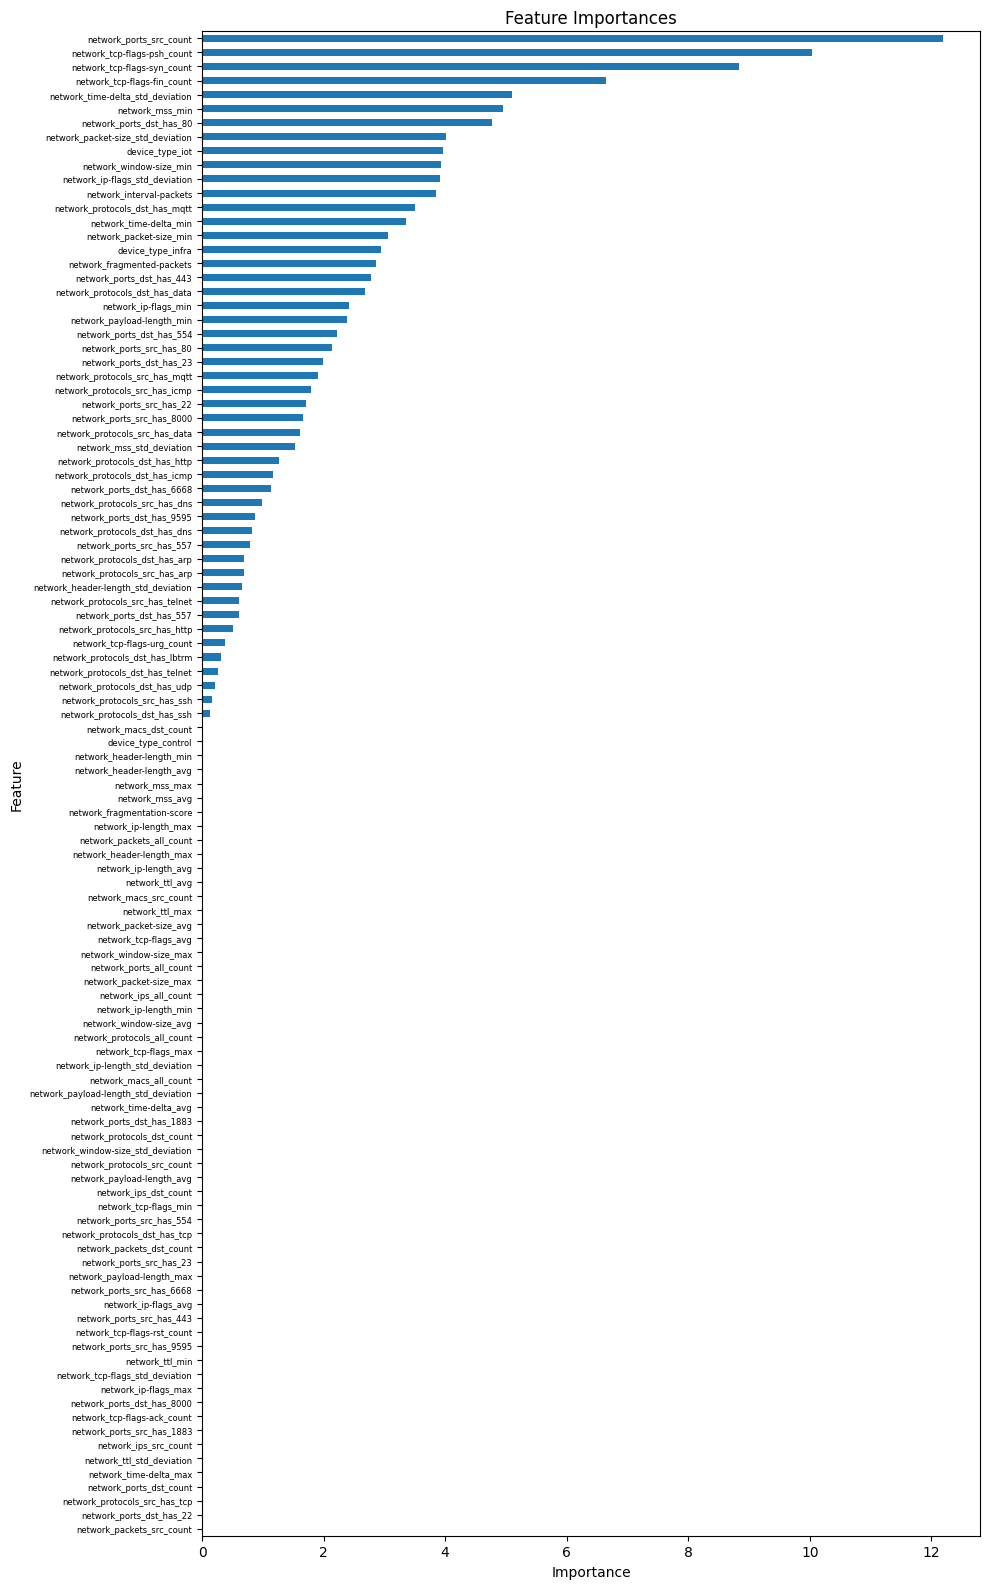

In [15]:
fig, ax = plt.subplots(figsize=(10, 16))

feature_importances["importance"].plot(kind="barh", ax=ax)

ax.invert_yaxis()
ax.set_yticks(
    ticks=range(feature_importances.shape[0]),
    labels=feature_importances["feature"],
    fontsize=6,
)
ax.set_title("Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(results_dir / "feature_importances.png", dpi=300)
plt.show()

# Model evaluations

## Train-split evaluations

In [16]:
y_proba = trained_pipe.predict_proba(X_train)

train_results = pd.DataFrame(
    data=y_proba,
    columns=trained_pipe.classes_,
    dtype="float32",
)

train_results.to_parquet(
    results_dir / "train_predict_proba.parquet",
    index=False,
    compression="gzip",
)

## Test-split evaluations

In [17]:
y_proba = trained_pipe.predict_proba(X_test)

test_results = pd.DataFrame(
    data=y_proba,
    columns=trained_pipe.classes_,
    dtype="float32",
)

test_results.to_parquet(
    results_dir / "test_predict_proba.parquet",
    index=False,
    compression="gzip",
)

# Model summary and persistency

## Model persistency

In [18]:
pipe_persist_path = results_dir / "pipe.pickle.gz"

with gz_open(pipe_persist_path, mode="wb") as pf:
    Pickler(pf, protocol=5).dump(trained_pipe)

## Model summary

In [19]:
model_summary = {
    "best_parameters": grid.best_params_,
    "all_parameters": trained_model.get_params(),
}

model_summary = dumps(model_summary, indent=2)
(results_dir / "model_summary.json").write_text(model_summary)
print("MODEL SUMMARY:", model_summary, sep="\n")

MODEL SUMMARY:
{
  "best_parameters": {
    "model__C": 10
  },
  "all_parameters": {
    "C": 10,
    "class_weight": "balanced",
    "dual": false,
    "fit_intercept": true,
    "intercept_scaling": 1,
    "l1_ratio": 0.0,
    "max_iter": 4000,
    "n_jobs": null,
    "penalty": "deprecated",
    "random_state": 12345,
    "solver": "lbfgs",
    "tol": 1e-05,
    "verbose": 0,
    "warm_start": false
  }
}
